In [1]:
# !pip install PyWavelets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import multiprocessing
from scipy.signal import butter, filtfilt
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV


In [2]:
# ======== FUNGSI PREPROCESSING ==========
"""
def remove_baseline_wander(ecg_signal, fs=500, cutoff=0.5, order=2):
    nyquist = 0.5 * fs
    low = cutoff / nyquist
    b, a = butter(order, low, btype='high')
    return filtfilt(b, a, ecg_signal)
"""

"\ndef remove_baseline_wander(ecg_signal, fs=500, cutoff=0.5, order=2):\n    nyquist = 0.5 * fs\n    low = cutoff / nyquist\n    b, a = butter(order, low, btype='high')\n    return filtfilt(b, a, ecg_signal)\n"

In [3]:

"""
def wavelet_denoising(ecg_signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(ecg_signal)))
    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs_thresh, wavelet)[:len(ecg_signal)]
"""

"\ndef wavelet_denoising(ecg_signal, wavelet='db6', level=4):\n    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)\n    sigma = np.median(np.abs(coeffs[-1])) / 0.6745\n    threshold = sigma * np.sqrt(2 * np.log(len(ecg_signal)))\n    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]\n    return pywt.waverec(coeffs_thresh, wavelet)[:len(ecg_signal)]\n"

In [4]:
"""
def wavelet_feature_extraction(ecg_signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
    return np.concatenate([coeffs[0], *coeffs[1:]])
"""

"\ndef wavelet_feature_extraction(ecg_signal, wavelet='db6', level=4):\n    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)\n    return np.concatenate([coeffs[0], *coeffs[1:]])\n"

In [5]:
"""
def preprocess_signal(ecg_signal):
    ecg_signal = remove_baseline_wander(ecg_signal)
    denoised_signal = wavelet_denoising(ecg_signal)
    return wavelet_feature_extraction(denoised_signal)
"""

'\ndef preprocess_signal(ecg_signal):\n    ecg_signal = remove_baseline_wander(ecg_signal)\n    denoised_signal = wavelet_denoising(ecg_signal)\n    return wavelet_feature_extraction(denoised_signal)\n'

In [6]:
"""
def preprocess_dataset(X):
    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())
    features = pool.map(preprocess_signal, X)
    pool.close()
    pool.join()
    return pd.DataFrame(features)
"""

'\ndef preprocess_dataset(X):\n    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())\n    features = pool.map(preprocess_signal, X)\n    pool.close()\n    pool.join()\n    return pd.DataFrame(features)\n'

In [7]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import pywt
from joblib import Memory, Parallel, delayed, dump
import time
import os

# ====== SETUP CACHE ======
cache_dir = "./ekg_cache"
os.makedirs(cache_dir, exist_ok=True)
memory = Memory(location=cache_dir, verbose=0)

# ====== FUNGSI PREPROCESSING DASAR ======
def remove_baseline_wander(ecg_signal, fs=500, cutoff=0.5, order=2):
    nyquist = 0.5 * fs
    low = cutoff / nyquist
    b, a = butter(order, low, btype='high')
    return filtfilt(b, a, ecg_signal)

def wavelet_denoising(ecg_signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(ecg_signal)))
    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs_thresh, wavelet)[:len(ecg_signal)]

def wavelet_feature_extraction(ecg_signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
    return np.concatenate([coeffs[0], *coeffs[1:]])

# ====== CACHE UNTUK FUNGSI UTAMA PER SINYAL ======
@memory.cache
def preprocess_signal_cached(ecg_signal):
    ecg_signal = remove_baseline_wander(ecg_signal)
    denoised = wavelet_denoising(ecg_signal)
    return wavelet_feature_extraction(denoised)

# ====== FUNGSI UNTUK SELURUH DATASET DENGAN JOBLIB ======
def preprocess_dataset(X):
    print("🚀 Mulai preprocessing seluruh dataset (dengan joblib)...")
    total_start = time.time()
    features = Parallel(n_jobs=-1)(
        delayed(preprocess_signal_cached)(x) for x in X
    )
    total_end = time.time()
    print(f"🏁 Semua data selesai dalam {total_end - total_start:.2f} detik")
    return pd.DataFrame(features)


In [8]:
# ======== LOADING  DATASET ==========
train_data = pd.read_csv(
    'dataset\mitbih_train.csv')
test_data = pd.read_csv(
    'dataset\mitbih_test.csv')

X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values

X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

# X_test = test_data.iloc[:, :-1].values
# y_test = test_data.iloc[:, -1].values.astype('int')

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_4872\3808878299.py:3: SyntaxWarning: invalid escape sequence '\m'
  'dataset\mitbih_train.csv')
C:\Users\user\AppData\Local\Temp\ipykernel_4872\3808878299.py:5: SyntaxWarning: invalid escape sequence '\m'
  'dataset\mitbih_test.csv')


In [9]:
X_train.dtype

dtype('float64')

In [10]:
y_train 

array([0., 0., 0., ..., 4., 4., 4.], shape=(87553,))

In [11]:
y_test

array([0., 0., 0., ..., 4., 4., 4.], shape=(21891,))

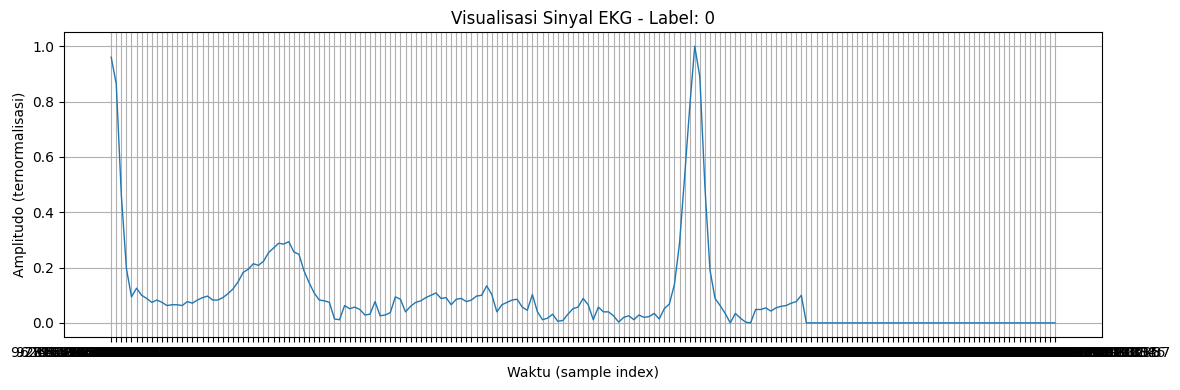

In [12]:
# Ambil 1 baris (misalnya baris ke-0)
sample_index = 0
sample_signal = train_data.iloc[sample_index, :-1]  # kolom 0 sampai 186
label = int(train_data.iloc[sample_index, -1])  # kolom ke-187

# Plot sinyal
plt.figure(figsize=(12, 4))
plt.plot(sample_signal, linewidth=1)
plt.title(f"Visualisasi Sinyal EKG - Label: {label}")
plt.xlabel("Waktu (sample index)")
plt.ylabel("Amplitudo (ternormalisasi)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# ======== PREPROCESS TRAINING DATA ==========
# tes uji coba
# Uji satu sinyal
# preprocessed_sample = preprocess_signal_cached(X_train[0])
# print("✅ Berhasil memproses 1 sinyal")


X_train_wavelet = preprocess_dataset(X_train)

🚀 Mulai preprocessing seluruh dataset (dengan joblib)...
🏁 Semua data selesai dalam 344.62 detik


In [14]:
# Normalisasi
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_wavelet)
# X_train_scaled = scaler.fit_transform(X_train)

In [15]:
# Feature Selection
num_features = 30
selector = SelectKBest(score_func=chi2, k=num_features)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

In [16]:
# Balancing Data
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_selected, y_train)

In [17]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(sampling_strategy={1: 5000, 3: 5000}, random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

# ======== PREPROCESS TESTING DATA (TIDAK BOLEH BALANCING) ==========
X_test_wavelet = preprocess_dataset(X_test)

🚀 Mulai preprocessing seluruh dataset (dengan joblib)...
🏁 Semua data selesai dalam 92.62 detik


In [18]:
y_train.dtype

dtype('float64')

In [19]:
y_test.dtype

dtype('float64')

In [20]:
# X_test_scaled = scaler.transform(X_test)

# Gunakan scaler dan selector dari training
X_test_scaled = scaler.transform(X_test_wavelet)
X_test_selected = selector.transform(X_test_scaled)

In [21]:
X_test_scaled

array([[0.26629578, 0.26415744, 0.26889091, ..., 0.41913903, 0.42794118,
        0.48549445],
       [0.18290205, 0.18368565, 0.18378882, ..., 0.41909189, 0.42805455,
        0.48540531],
       [0.11016755, 0.10643915, 0.1152227 , ..., 0.41898896, 0.42792385,
        0.48551495],
       ...,
       [0.14533353, 0.14195162, 0.148787  , ..., 0.41887529, 0.42814757,
        0.48541501],
       [0.27030333, 0.2844426 , 0.28695145, ..., 0.41879491, 0.42823753,
        0.48536133],
       [0.31115997, 0.32716839, 0.33483987, ..., 0.41899285, 0.42807448,
        0.48542966]], shape=(21891, 231))

In [22]:
X_test_selected

array([[0.26629578, 0.26415744, 0.26889091, ..., 0.48261705, 0.27390071,
        0.46501146],
       [0.18290205, 0.18368565, 0.18378882, ..., 0.4836348 , 0.29184702,
        0.65032426],
       [0.11016755, 0.10643915, 0.1152227 , ..., 0.45494606, 0.24912686,
        0.44589109],
       ...,
       [0.14533353, 0.14195162, 0.148787  , ..., 0.47794319, 0.19425686,
        0.39553585],
       [0.27030333, 0.2844426 , 0.28695145, ..., 0.38190991, 0.41139017,
        0.67909338],
       [0.31115997, 0.32716839, 0.33483987, ..., 0.33514629, 0.45480693,
        0.47308404]], shape=(21891, 30))

In [23]:
# ======== TRAINING MODEL ==========
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [24]:
# UNTUK SCALE_POS_WEIGHT nanti

# xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
# tree_method='hist')
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',scale_pos_weight={1: x, 3: y}, tree_method='hist')
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    # Sesuaikan bobot sesuai proporsi data
    scale_pos_weight={0: 1, 1: 10, 2: 1, 3: 8, 4: 1}
)
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_grid, n_iter=20, cv=3, verbose=2, n_jobs=-1)
random_search.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Code and Application\Data Science\FarelEKG\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:18:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 6, 10],
                                        'n_estimators': [100, 200, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   verbose=2)

In [26]:
# Setelah training, simpan model terbaik
best_model = random_search.best_estimator_

# Simpan model ke file
dump(best_model, "model/xgb_model_ekg.joblib")
print("Model berhasil disimpan 🚀")

Model berhasil disimpan 🚀


In [27]:
# ======== EVALUASI MODEL ==========
y_pred = random_search.best_estimator_.predict(X_test_selected)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9778
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18117
         1.0       0.77      0.74      0.76       556
         2.0       0.95      0.94      0.95      1448
         3.0       0.78      0.81      0.79       162
         4.0       0.99      0.98      0.98      1608

    accuracy                           0.98     21891
   macro avg       0.90      0.89      0.89     21891
weighted avg       0.98      0.98      0.98     21891



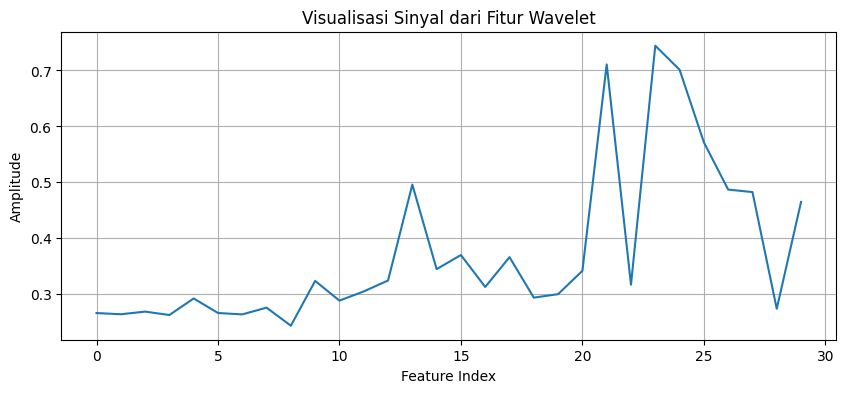

In [31]:
# Misal ambil satu sample
sample_idx = 0
sample = X_test_selected[sample_idx]

# 1. Visualisasikan fitur wavelet sebagai sinyal
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(sample)), sample)
plt.title('Visualisasi Sinyal dari Fitur Wavelet')
plt.xlabel('Feature Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [28]:
y_pred

array([0, 0, 0, ..., 4, 4, 4], shape=(21891,))

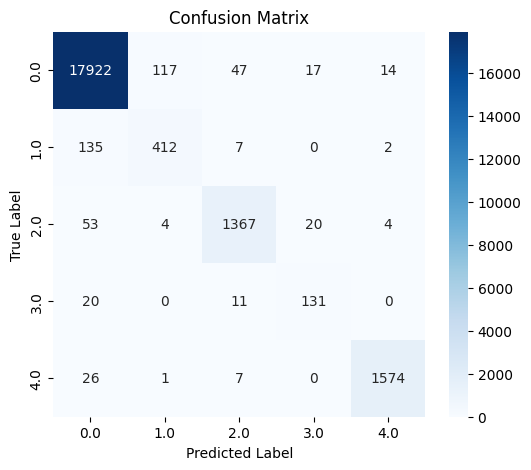

In [29]:
# ======== CONFUSION MATRIX ==========
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [30]:
# Akurasi per kelas
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_accuracies):
    print(f"Akurasi kelas {i}: {acc:.4f}")

Akurasi kelas 0: 0.9892
Akurasi kelas 1: 0.7410
Akurasi kelas 2: 0.9441
Akurasi kelas 3: 0.8086
Akurasi kelas 4: 0.9789
